In [18]:
import pandas as pd
import numpy as np

df = pd.read_excel(r"C:\Users\Admin\Downloads\Employee Data.xlsx")

print("--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())

print("\n--- Data Types ---")
print(df.dtypes)

--- Missing Values ---
Model                               0
Name                                0
Email                               0
Director                            0
Senior Manager                      0
Please select your Manager Name:    0
Please enter your Employee ID:      0
Please enter your Dell Email ID:    0
Gender                              0
Job Level                           0
Attendance                          0
Team                                0
Attendance Status                   0
Salary                              0
Date                                0
Month                               0
Quarter                             0
Bonus                               0
dtype: int64

--- Duplicate Rows ---
0

--- Data Types ---
Model                                       object
Name                                        object
Email                                       object
Director                                    object
Senior Manager                

In [34]:
import pandas as pd
import numpy as np


file_path = r"C:\Users\Admin\Downloads\Employee Data.xlsx"
df = pd.read_excel(file_path) 


column_mapping = {
    'Please select your Manager Name:': 'Manager_Name',
    'Please enter your Employee ID:': 'Employee_ID',
    'Please enter your Dell Email ID:': 'Dell_Email',
    'Job Level': 'Job_Level',
    'Attendance Status': 'Attendance_Status'
}
df.rename(columns=column_mapping, inplace=True)


df['Job_Level'] = df['Job_Level'].replace('Anyalst', 'Analyst')


df['Model'] = df['Model'].str.strip()


df['Date'] = pd.to_datetime(df['Date'])


df['Total_Compensation'] = df['Salary'] + df['Bonus']


df = df.dropna(how='all') 


df.to_csv('cleaned_employee_data.csv', index=False)

print("--- Data Cleaning Summary ---")
print(f"Total Records: {len(df)}")
print(f"Unique Job Levels: {df['Job_Level'].unique()}")
print("Cleaned file saved as: 'cleaned_employee_data.csv'")

print(df.head())

--- Data Cleaning Summary ---
Total Records: 38
Unique Job Levels: ['Executive' 'Senior Executive' 'Analyst' 'Senior Analyst' 'Team Lead']
Cleaned file saved as: 'cleaned_employee_data.csv'
   Model     Name                         Email Director Senior Manager  \
0  Basic    James    James Tony@Sample_Demo.com   Morris            Dan   
1  Basic     John     John Tony@Sample_Demo.com   Morris          Lewis   
2  Basic   Robert   Robert Tony@Sample_Demo.com   Morris            Sam   
3  Basic  Michael  Michael Tony@Sample_Demo.com   Morris           Kent   
4  Basic  William  William Tony@Sample_Demo.com   Morris           Wade   

  Manager_Name  Employee_ID               Dell_Email  Gender  \
0          Dan      8645382    James Tony@Sample.com    Male   
1        Lewis      8645383     John Tony@Sample.com    Male   
2          Sam      8645384   Robert Tony@Sample.com    Male   
3         Kent      8645385  Michael Tony@Sample.com  Female   
4         Wade      8645386  William To

Average Bonus based on Attendance:
Attendance
Absent     900.000000
Present    910.606061
Name: Bonus, dtype: float64


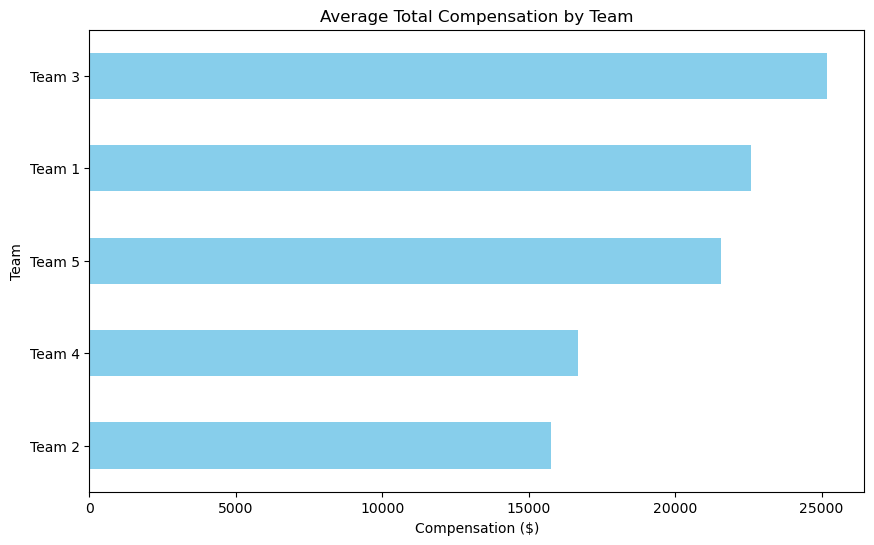

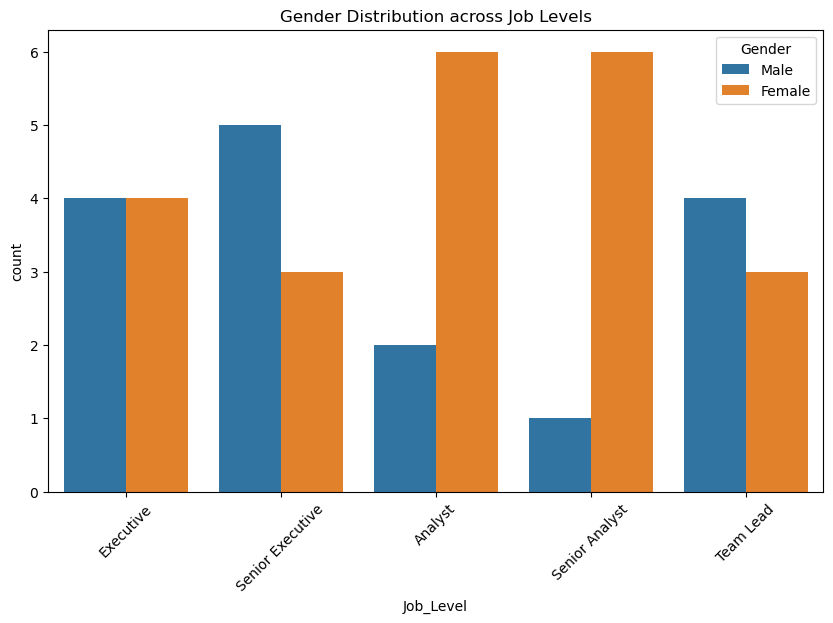

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data
df = pd.read_csv('cleaned_employee_data.csv')

# Insight 1: Average Salary by Team
plt.figure(figsize=(10, 6))
team_salary = df.groupby('Team')['Total_Compensation'].mean().sort_values()
team_salary.plot(kind='barh', color='skyblue')
plt.title('Average Total Compensation by Team')
plt.xlabel('Compensation ($)')
plt.savefig('team_salary_analysis.png')

# Insight 2: Attendance vs Salary
# Does higher attendance correlate with higher bonuses?
attendance_impact = df.groupby('Attendance')['Bonus'].mean()
print("Average Bonus based on Attendance:")
print(attendance_impact)

# Insight 3: Gender Distribution in Job Levels
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Job_Level', hue='Gender')
plt.title('Gender Distribution across Job Levels')
plt.xticks(rotation=45)
plt.savefig('gender_distribution.png')